# TP18 - Implémentation et Visualisation des Graphes

## Exercice 1 : Métro de Graphetown
!!! info Contexte
Pour ce TP, nous allons modéliser le réseau de transport de **Graphetown**. \
Le réseau est composé de 6 stations : **A, B, C, D, E et F**.\
Nous allons explorer deux manières de représenter ce réseau en machine : par une **matrice d'adjacence** et par une **liste d'adjacence**.
!!!
!!! example Le réseau 
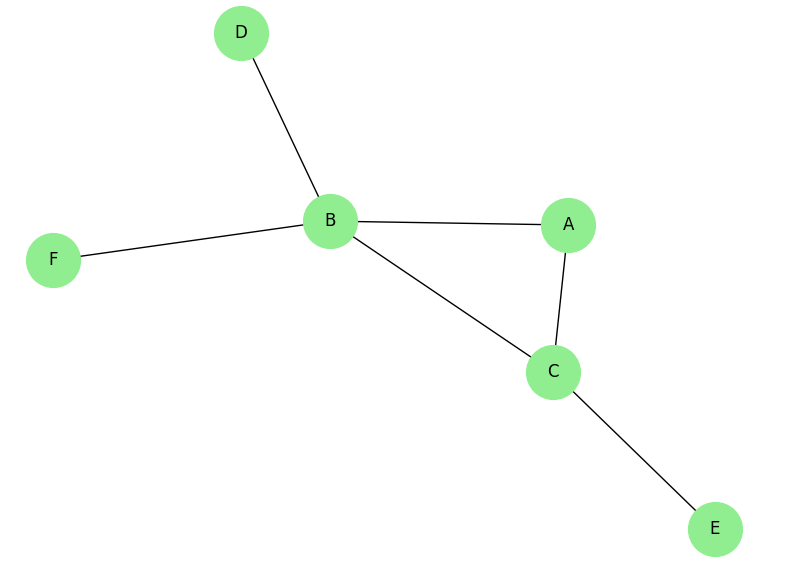
!!!

!!! question Question 1
Proposer une implémentation de ce graphe sous forme d'une matrice d'adjacence nommée `matrice_metro`. On utilisera une liste de listes (de booléens ou d'entier (1 ou 0) au choix).\
*(Ordre des sommets : 0:A, 1:B, 2:C, ...)*
!!!

!!! question Question 2
Écrire une fonction `sont_voisins_mat(m: list[list], i: int, j: int) -> bool` qui prend en paramètre `m` la matrice et les indices `i` et`j` associé à 2 stations, et renvoie `True` s'il existe une ligne direct entre elles, `False` sinon.\
**Donnez sa complexité**
!!!

In [ ]:
print(sont_voisins_mat(matrice_metro, 0, 2)) #True

In [ ]:
print(sont_voisins_mat(matrice_metro, 4, 3)) #False

!!! question Question 3
Écrire une fonction `degre_mat(m: list[list], i: int) -> int` qui renvoie le degré du sommet à l'indice `i`.
!!!

In [ ]:
print(degre_mat(matrice_metro, 1)) #4

!!! info Bibliothèques
Pour afficher le graphe, nous allons utiliser `networkx` pour la structure et `matplotlib.pyplot` pour le rendu visuel.
!!!
**Lire et exécuter la fonction suivante**

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def afficher_graphe_mat(m):
    # Votre matrice d'adjacence
    matrix = np.array(m)

    # Création du graphe
    G = nx.from_numpy_array(matrix)

    # Affichage
    plt.figure(figsize=(8, 6))
    nx.draw(G, with_labels=True, node_color='lightgreen', node_size=1500)
    plt.show()

In [ ]:
afficher_graphe_mat(matrice_metro)

!!! question Question 4
Maintenant représenter le même graphe mais en utilisant une liste d'adjacence nommé `dico_metro`. Vous utiliserez un dictionnaire où les clés seront le nom des stations ("A", "B"...) et les valeurs seront les listes de stations voisines.
!!!

!!! question Question 5
Écrire une fonction `sont_voisins_dico(dico: dict[str:list[str]], s1: str, s2: str) -> bool` qui prend en paramètre `dico` le dictopnnaire représentant la liste d'adjacence du graphe et les stations `s1` et`s2`, et renvoie `True` s'il existe une ligne direct entre elles, `False` sinon.\
**Donnez sa complexité**
!!!

In [ ]:
print(sont_voisins_dico(dico_metro, "A", "C")) #True

In [ ]:
print(sont_voisins_dico(dico_metro, "E", "D")) #False

!!! question Question 6
Écrire une fonction `degre_dico(dico: dict[str:list[str], s: str) -> int` qui renvoie le degré du sommet `s`.
!!!

In [ ]:
print(degre_dico(dico_metro, "B")) #4

**Visualisation de notre graphe par liste d'adjacence** \
On rajoute un paramètre optionnel digraphe qui dit si notre graphe est un digraphe (s'il est orienté) ou non.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def afficher_graphe_liste(dico, digraphe = False):
    # Création du graphe orienté à partir du dictionnaire
    if digraphe:
        G = nx.DiGraph(dico)
    else:
        G = nx.Graph(dico)

    # Dessin
    plt.figure(figsize=(8, 6))
    nx.draw(G, with_labels=True, node_color='lightgreen', node_size=1500)
    plt.show()

In [ ]:
afficher_graphe_liste(dico_metro)

!!! question Question 7
Écrire une fonction `matrice_vers_dico(m, noms_sommets)` qui prend en argument la matrice d'adjacence et la liste des noms des sommets, et renvoie le dictionnaire (liste d'adjacence) correspondant.
!!!

In [ ]:
print(matrice_vers_dico(matrice_metro, ["A", "B", "C", "D", "E", "F"]) == dico_metro) #True

## Exercice 2 : Route à sens unique

!!! info Contexte
On modélise maintenant les routes de GrapheTown, en sachant qu'il y a beaucoup de sens unique. Le graphe est donc **orienté**.
Nous allons directement utiliser un **dictionnaire** pour représenter les listes d'adjacence : les clés sont les noms des croisement et les valeurs sont les listes de leurs successeurs (croisement vers lequel on peut aller).
!!!

!!! example Plan
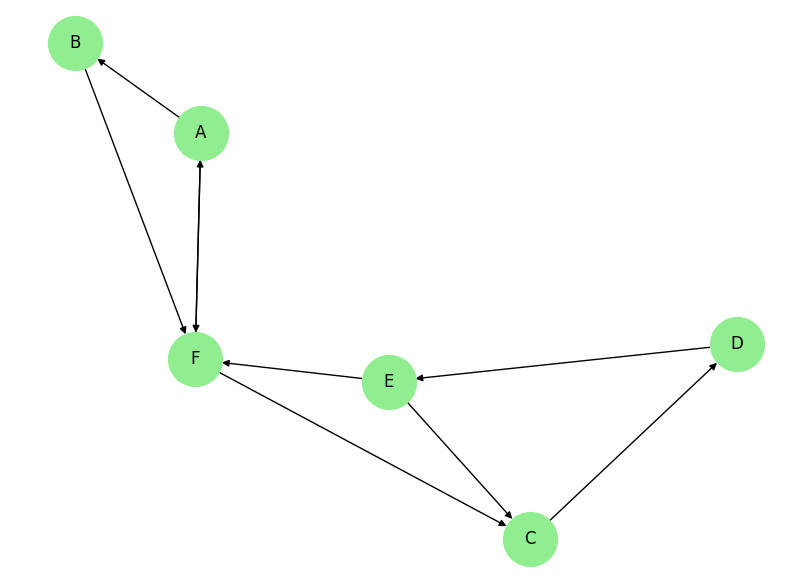
!!!

!!! question Question 1
Définir le dictionnaire `dico_route` correspondant à ce nouveau plan.
!!!

!!! question Question 2
Visualiser votre graphe à l'aide de la fonction `afficher_graphe_liste()`.
!!!

!!! question Question 3
Écrire la fonction `est_successeur(dico, v: str, u: str) -> bool` qui renvoie `True` si `v` est un successeur de `u` et `False` sinon.
!!!

In [ ]:
print(est_successeur(dico_route, "E", "D")) #True

In [ ]:
print(est_successeur(dico_route, "D", "E")) #False

!!! question Question 4
Écrire la fonction `est_predecesseur(dico, u: str, v: str) -> bool` qui renvoie `True` si `u` est un prédécesseur de `v` et `False` sinon.
!!!

In [ ]:
print(est_predecesseur(dico_route, "E", "D")) #False

In [ ]:
print(est_predecesseur(dico_route, "D", "E")) #True

!!! question Question 5
Écrire une fonction `degre_sortant(dico, s) -> int` qui donne le degré sortant du sommet `s`.\
**Donner la complexité de cette fonction**
!!!

In [ ]:
print(degre_sortant(dico_route, 'F'))#2

!!! question Question 6
Écrire une fonction `degre_entrant(dico, s) -> int` qui donne le degré entrant du sommet `s`.\
**Donner la complexité de cette fonction en fonction de $|S|$ le nombre de sommet et $|A|$ le nombre d'arc**
!!!

In [ ]:
print(degre_entrant(dico_route, 'F'))#3

!!! question Question 7
La municipalité veut installer repérer le(s) croisement(s) où il y a le plus de passage.\
Écrire une fonction `croisement_majeure(dico[str:list[str]])-> list[str]` qui renvoie le(s) nom(s) de(s) la station(s) ayant le degré (total) le plus élevé.
!!!

In [ ]:
print(croisement_majeure(dico_route)) #['F']

!!! question Question 8
Un usager propose l'itinéraire suivant : `["A", "B", "D", "F"]`.\
Écrire une fonction `est_chemin_valide(dico, liste_sommets)` qui renvoie `True` si chaque sommet de la liste est bien reliée à la suivante dans le graphe `dico`, et `False` sinon.
!!!

In [ ]:
print(est_chemin_valide(dico_route, ["A", "B", "D", "F"])) # False

In [ ]:
print(est_chemin_valide(dico_route, ["A", "B", "F", "C", "D"]))# True

!!! question Question 9 : Bonus
Modifier la fonction `afficher_graphe_liste()` pour qu'elle prenne en compte le(s) croisement(s) majeure(s) qui seront représenté en rouge.

Dans `nx.draw()` vous pouvez passer en paramètre `node_color` qui est soit une couleur unique (ex `'lightgreen'` pour tous les sommets, soit une liste de couleurs pour les sommets.
!!!

In [ ]:
afficher_graphe_liste_majeurs(dico_route, True)